# Etapa 3 — Pipeline de Detección y Clasificación de Razas de Perros

## Configuración

In [1]:
import sys
import os
from pathlib import Path
from dotenv import load_dotenv

ROOT = Path.cwd()
src_path = str(ROOT / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)

env_file = ROOT / ".env.local.example" 
if not env_file.exists():
    env_file = ROOT / "src" / ".env.local.example"

load_dotenv(env_file)


def parse_path(env_value: str) -> Path:
    clean_path = env_value.replace("../", "")
    return ROOT / clean_path

DATASET_PATH = parse_path(os.getenv("DATASET_PATH", "../data/dataset"))
OUTPUT_PATH  = parse_path(os.getenv("OUTPUT_PATH", "../output"))
IMAGE_SIZE   = int(os.getenv("IMAGE_SIZE", 224))

MODEL_PATH = parse_path(os.getenv("MODEL_PATH", "../models"))
CHECKPOINTS = {
    "resnet18_finetuned": MODEL_PATH / os.getenv("RESNET18_MODEL_NAME", "resnet18_finetuned.pth"),
    "cnn_custom": MODEL_PATH / os.getenv("CNN_CUSTOM_MODEL_NAME", "cnn_custom.pth"),
}

YOLO_MODEL_NAME = os.getenv("YOLO_MODEL", "yolov8n.pt")
CONF_THRESHOLD  = float(os.getenv("YOLO_CONF_THRESHOLD", 0.25))
DOG_CLASS_ID    = int(os.getenv("YOLO_DOG_CLASS_ID", 16))
 
ACTIVE_MODEL = "resnet18_finetuned"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [2]:
from lib.services.classifier_service import ClassifierService
from lib.services.detection_service import DetectionService

classifier = ClassifierService(
    checkpoints=CHECKPOINTS,
    image_size=IMAGE_SIZE,
    dataset_path=DATASET_PATH,
    output_path=OUTPUT_PATH,
    active_model=ACTIVE_MODEL,
)

detector = DetectionService(
    classifier=classifier,
    yolo_model=YOLO_MODEL_NAME,
    conf_threshold=CONF_THRESHOLD,
    dog_class_id=DOG_CLASS_ID,
)


## Función de visualización del pipeline completo

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def run_pipeline(image_path: str, figsize=(10, 8), show=True):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")

    
    height, width = image.shape[:2]
    detections = []
    raw_detections = detector.detect_dogs(image)

    
    for (box, det_score) in raw_detections:
        x1, y1, x2, y2 = detector._clip_xyxy(*[int(v) for v in box], height, width)
        crop = image[y1:y2, x1:x2]    
        breed, breed_score = detector.classify_detected_dog(crop) 
        detections.append(((x1, y1, x2, y2), det_score, breed, breed_score))

    
    if show:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        fig, ax = plt.subplots(1, 1, figsize=figsize)
        ax.imshow(image_rgb)

        for (x1, y1, x2, y2), det_score, breed, breed_score in detections:
            rect = mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="lime", linewidth=2,
            )
            ax.add_patch(rect)
            label = f"{breed} {breed_score:.2f} | det {det_score:.2f}"
            ax.text(
                x1, max(0, y1 - 4), label,
                color="white", fontsize=9,
                bbox=dict(facecolor="darkgreen", alpha=0.75, pad=1),
            )

        ax.set_title(f"{len(detections)} perro(s) detectado(s) (conf \u2265 {CONF_THRESHOLD})", fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

        if not detections:
            print("\u26a0\ufe0f  No se detectó ningún perro en la imagen.")
        for i, (_, det_score, breed, breed_score) in enumerate(detections, 1):
            print(f"  Perro {i}: raza='{breed}' | score clasificación={breed_score:.3f} | conf. detección={det_score:.3f}")

    return detections

## Un solo perro

Imagen: c:\Users\fjm25\Desktop\Facundo\TUIA\CV\tp2\tuia-dog-recognition-app\data\dataset\test\Irish Spaniel\05.jpg | Raza real: Irish Spaniel

0: 640x640 (no detections), 278.4ms
Speed: 15.0ms preprocess, 278.4ms inference, 10.7ms postprocess per image at shape (1, 3, 640, 640)


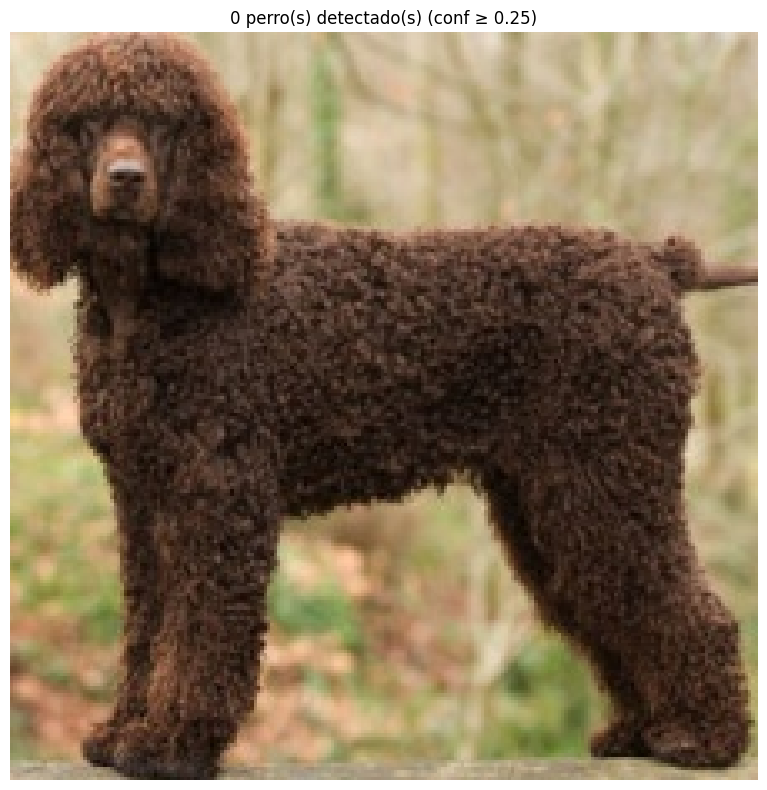

⚠️  No se detectó ningún perro en la imagen.


[]

In [4]:
import random

todas_las_imagenes = list((DATASET_PATH / "test").rglob("*.jpg"))

sample_image = random.choice(todas_las_imagenes)

raza_real = sample_image.parent.name

print(f"Imagen: {sample_image} | Raza real: {raza_real}")

run_pipeline(str(sample_image))

## Multiples perros en la misma imagen


0: 448x640 7 dogs, 151.2ms
Speed: 7.9ms preprocess, 151.2ms inference, 26.6ms postprocess per image at shape (1, 3, 448, 640)


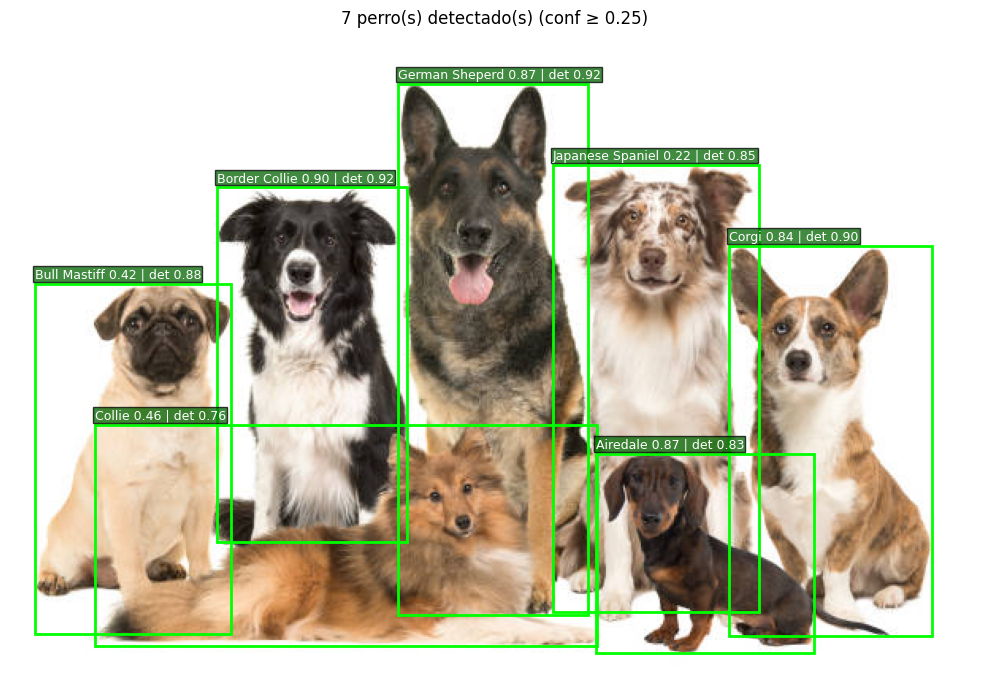

  Perro 1: raza='Border Collie' | score clasificación=0.900 | conf. detección=0.924
  Perro 2: raza='German Sheperd' | score clasificación=0.867 | conf. detección=0.920
  Perro 3: raza='Corgi' | score clasificación=0.843 | conf. detección=0.899
  Perro 4: raza='Bull Mastiff' | score clasificación=0.420 | conf. detección=0.879
  Perro 5: raza='Japanese Spaniel' | score clasificación=0.221 | conf. detección=0.850
  Perro 6: raza='Airedale' | score clasificación=0.873 | conf. detección=0.831
  Perro 7: raza='Collie' | score clasificación=0.462 | conf. detección=0.760


[((130, 98, 250, 322),
  0.9237492084503174,
  'Border Collie',
  0.8996341228485107),
 ((244, 33, 364, 368), 0.9201022386550903, 'German Sheperd', 0.86737060546875),
 ((453, 135, 581, 381), 0.8988335132598877, 'Corgi', 0.8426662683486938),
 ((15, 159, 139, 380), 0.8790320158004761, 'Bull Mastiff', 0.4196445047855377),
 ((342, 84, 472, 366),
  0.8500434756278992,
  'Japanese Spaniel',
  0.22086657583713531),
 ((369, 266, 507, 392), 0.831108570098877, 'Airedale', 0.8731691837310791),
 ((53, 248, 370, 387), 0.7600221633911133, 'Collie', 0.46184805035591125)]

In [5]:
run_pipeline("data/dataset/multiples_perros_2.jpg")

## Escena compleja (perros + otros objetos)

0: 384x640 1 dog, 3 teddy bears, 268.2ms
Speed: 7.1ms preprocess, 268.2ms inference, 10.4ms postprocess per image at shape (1, 3, 384, 640)


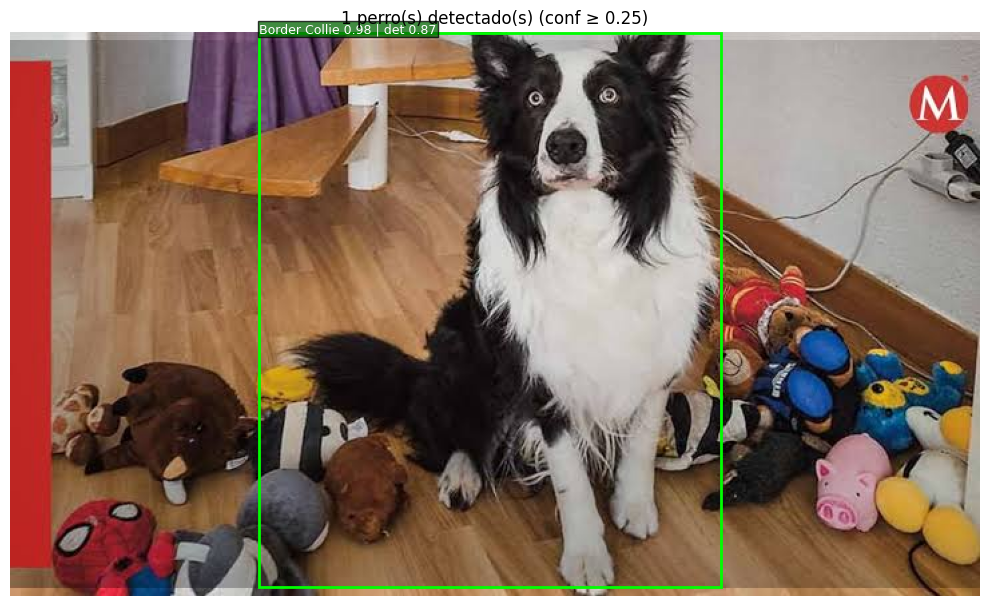

  Perro 1: raza='Border Collie' | score clasificación=0.975 | conf. detección=0.870


[((186, 0, 532, 415), 0.8700541853904724, 'Border Collie', 0.9752886891365051)]

In [6]:
run_pipeline("data/dataset/perros_objetos.jpg")